Qual é a melhor hora do dia/dia da semana/época do ano para voar e minimizar os atrasos?
Os aviões mais antigos sofrem mais atrasos?
Como o número de pessoas que voam entre diferentes locais muda ao longo do tempo?
Qual é a capacidade do clima de prever atrasos nos aviões?
É possível detectar falhas em cascata, pois os atrasos em um aeroporto geram atrasos em outros? Existem links críticos no sistema?

Os dados consistem em detalhes de chegada e partida de todos os voos comerciais nos EUA, de outubro de 1987 a abril de 2008. Trata-se de um grande conjunto de dados: há quase 120 milhões de registros no total.

Você também pode trabalhar com subconjuntos interessantes: talvez queira comparar os padrões de voo antes e depois do 11 de setembro, ou entre os pares de cidades entre as quais você voa com mais frequência, ou todos os voos de e para um aeroporto importante como Chicago (ORD). Subconjuntos menores também podem ajudá-lo a combinar os dados com outros conjuntos de dados interessantes.

## **IMPORTS**

In [5]:
# Apache Spark API
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import col, count, upper, round, isnan, sum

# Data Handling
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

In [6]:
# Iniciando Spark Session
spark = SparkSession.builder \
    .appName("BigData_AC2") \
    .master("local[*]") \
    .config("spark.executor.memory", "12g") \
    .config("spark.driver.memory",   "12g") \
    .getOrCreate()

In [7]:
# Definição de Schema dos dados
df = spark.read.schema(
    StructType([
        StructField(name="Year", dataType=LongType(), nullable=True),
        StructField(name="Month", dataType=LongType(), nullable=True),
        StructField(name="DayofMonth", dataType=LongType(), nullable=True),
        StructField(name="DayOfWeek", dataType=LongType(), nullable=True),
        StructField(name="DepTime", dataType=DoubleType(), nullable=True),
        StructField(name="CRSDepTime", dataType=LongType(), nullable=True),
        StructField(name="ArrTime", dataType=DoubleType(), nullable=True),
        StructField(name="CRSArrTime", dataType=LongType(), nullable=True),
        StructField(name="UniqueCarrier", dataType=StringType(), nullable=True),
        StructField(name="FlightNum", dataType=LongType(), nullable=True),
        StructField(name="TailNum", dataType=StringType(), nullable=True),
        StructField(name="ActualElapsedTime", dataType=DoubleType(), nullable=True),
        StructField(name="CRSElapsedTime", dataType=DoubleType(), nullable=True),
        StructField(name="AirTime", dataType=DoubleType(), nullable=True),
        StructField(name="ArrDelay", dataType=DoubleType(), nullable=True),
        StructField(name="DepDelay", dataType=DoubleType(), nullable=True),
        StructField(name="Origin", dataType=StringType(), nullable=True),
        StructField(name="Dest", dataType=StringType(), nullable=True),
        StructField(name="Distance", dataType=DoubleType(), nullable=True),
        StructField(name="TaxiIn", dataType=DoubleType(), nullable=True),
        StructField(name="TaxiOut", dataType=DoubleType(), nullable=True),
        StructField(name="Cancelled", dataType=LongType(), nullable=True),
        StructField(name="isDelay", dataType=IntegerType(), nullable=True),
    ])
).parquet("../../../data/airline_clean.parquet", header=True)
print(f"N° samples: {df.count()}")

N° samples: 74008262


## **DATA TREATMENT**

In [8]:
# Normalizando colunas do tipo string
df = df.withColumn("Origin", upper(col('Origin')))

## **EXPLORATION DATA ANALYSIS**

### QUESTÃO 1 - Qual é a melhor dia da semana/época do ano para voar e minimizar os atrasos?

In [9]:
# Melhor mês do ano para viajar, com maiores chances de não atrasar e não cancelar cancelar é em setembro
(
    df.groupBy(
        'Month', 'isDelay', 'Cancelled'
    ).agg(
        round((count("isDelay") / df.count())*100, 4).alias("probability_delay"),
        round((count("Cancelled") / df.count())*100, 4).alias("probability_cancelled")
    ).filter(
        (col('isDelay') == 0) & (col('Cancelled') == 0)
    ).orderBy(
        *['probability_delay', 'probability_cancelled'], ascending=False
).show())

+-----+-------+---------+-----------------+---------------------+
|Month|isDelay|Cancelled|probability_delay|probability_cancelled|
+-----+-------+---------+-----------------+---------------------+
|    9|      0|        0|           5.4929|               5.4929|
|   10|      0|        0|           5.3854|               5.3854|
|    5|      0|        0|           5.3737|               5.3737|
|    8|      0|        0|           5.2645|               5.2645|
|    4|      0|        0|            5.236|                5.236|
|    3|      0|        0|           5.1266|               5.1266|
|    7|      0|        0|           5.0941|               5.0941|
|   11|      0|        0|           5.0696|               5.0696|
|    1|      0|        0|            4.809|                4.809|
|    6|      0|        0|           4.6871|               4.6871|
|    2|      0|        0|           4.4833|               4.4833|
|   12|      0|        0|           4.3937|               4.3937|
+-----+---

In [10]:
# O melhor dia da semana, que tem maior probabilidade de não atrasar e não cancelar é na terça-feira
(
    df.groupBy(
        'DayOfWeek', 'isDelay', 'Cancelled'
    ).agg(
        round((count("isDelay") / df.count())*100, 4).alias("probability_delay"),
        round((count("Cancelled") / df.count())*100, 4).alias("probability_cancelled")
    ).filter(
        (col('isDelay') == 0) & (col('Cancelled') == 0)
    ).orderBy(
        *['probability_delay', 'probability_cancelled'], ascending=False
).show())

+---------+-------+---------+-----------------+---------------------+
|DayOfWeek|isDelay|Cancelled|probability_delay|probability_cancelled|
+---------+-------+---------+-----------------+---------------------+
|        2|      0|        0|           9.1799|               9.1799|
|        1|      0|        0|           8.9687|               8.9687|
|        3|      0|        0|           8.9062|               8.9062|
|        7|      0|        0|           8.5213|               8.5213|
|        6|      0|        0|           8.4542|               8.4542|
|        4|      0|        0|           8.3047|               8.3047|
|        5|      0|        0|           8.0809|               8.0809|
+---------+-------+---------+-----------------+---------------------+



In [11]:
# Os melhores dias do mês, para ter maior chance de não atrasar e não cancelar o voo, é nos primeiros dias do mês.
(
    df.groupBy(
        'DayofMonth', 'isDelay', 'Cancelled'
    ).agg(
        round((count("isDelay") / df.count())*100, 4).alias("probability_delay"),
        round((count("Cancelled") / df.count())*100, 4).alias("probability_cancelled")
    ).filter(
        col('isDelay') == 0
    ).orderBy(
        *['probability_delay', 'probability_cancelled'], ascending=False
).show())

+----------+-------+---------+-----------------+---------------------+
|DayofMonth|isDelay|Cancelled|probability_delay|probability_cancelled|
+----------+-------+---------+-----------------+---------------------+
|         4|      0|        0|           2.0405|               2.0405|
|         3|      0|        0|            2.038|                2.038|
|         9|      0|        0|           2.0224|               2.0224|
|         6|      0|        0|           2.0211|               2.0211|
|         8|      0|        0|           2.0199|               2.0199|
|         5|      0|        0|           2.0194|               2.0194|
|        10|      0|        0|           2.0153|               2.0153|
|         2|      0|        0|           2.0148|               2.0148|
|         7|      0|        0|           2.0134|               2.0134|
|        25|      0|        0|           2.0097|               2.0097|
|         1|      0|        0|           2.0011|               2.0011|
|     

### QUESTÃO 2 - Como o número de pessoas que voam entre diferentes locais muda ao longo do tempo?

In [12]:
# 1 https://pt.wikipedia.org/wiki/Atlanta -> Referência de justificativa do aumento de voos para atlanta na década de 2000
# 2 Em 2000, o Eppley Airfield de Omaha era o maior aeroporto de Nebraska, atendendo a 5 milhões de passageiros por ano.
# Ele oferecia serviço sem parada para 31 dos aeroportos mais movimentados do país e tinha mais de 200 chegadas e partidas diárias.
# Embora não seja específico para voos entre o ORD (Aeroporto Internacional O'Hare de Chicago) e Nebraska, essas informações indicam
# que Omaha era um importante centro de viagens aéreas em Nebraska.
# 3 https://en.wikipedia.org/wiki/Dallas_Fort_Worth_International_Airport -> Um dos maiores aeroportos dos Estados Unidos

(
    df.groupBy(
        'Year','Dest'
    ).agg(
         count("Dest").alias("count"),
    ).orderBy(
        *['count', 'Year'], ascending=False
).show())

# 1 Atlanta
# 2 ORD Nebraska
# 3 DFW (Dallas Fort Worth International Airport)

+----+----+------+
|Year|Dest| count|
+----+----+------+
|2008| ATL|350268|
|2007| ATL|345443|
|2005| ATL|343691|
|2004| ATL|343588|
|2006| ATL|328508|
|2003| ATL|321363|
|2004| DFW|300708|
|2003| ORD|300355|
|2003| DFW|298870|
|2004| ORD|291586|
|2006| ORD|283983|
|2002| ORD|280313|
|2007| ORD|278273|
|2005| ORD|275549|
|2001| ORD|274136|
|2005| DFW|272098|
|2001| DFW|268311|
|2008| ORD|260490|
|2006| DFW|259733|
|1997| ORD|259518|
+----+----+------+
only showing top 20 rows



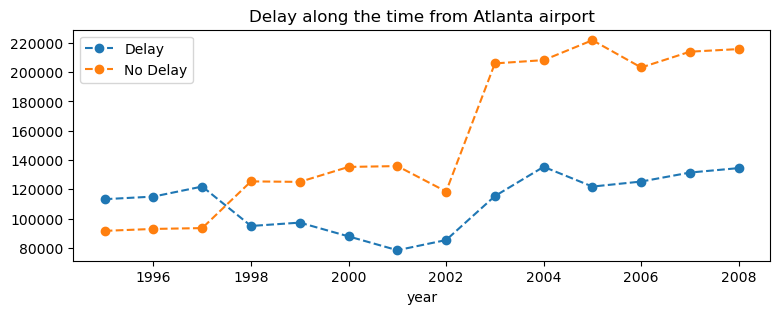

In [13]:
# Percebe-se o aumento de viagens ao longo do tempo para o aeroporto de Atlanta
# Ainda, a melhoria na infraestrutura do aeroporto, diminuindo o atraso de voos ao longo do tempo
# Um grande aumento nos voos com destino para Atlanta, na década dos anos 2000
plot_data = df.filter(
    (col('Dest') == 'ATL')
).groupBy(
    'Dest', 'IsDelay', 'Year'
).agg(
    count("IsDelay").alias("count")
).orderBy('Year')

x = plot_data.filter(col('isDelay') == 1).select('Year').rdd.flatMap(list).collect()
y1 = plot_data.filter(col('isDelay') == 1).select('count').rdd.flatMap(list).collect()
y2 = plot_data.filter(col('isDelay') == 0).select('count').rdd.flatMap(list).collect()

plt.figure(figsize=(9,3))
plt.plot(x, y1, label='Delay', marker='o', linestyle='dashed')
plt.plot(x, y2, label='No Delay', marker='o', linestyle='dashed')
plt.xlabel('year')
plt.title('Delay along the time from Atlanta airport')
plt.legend()
plt.show()

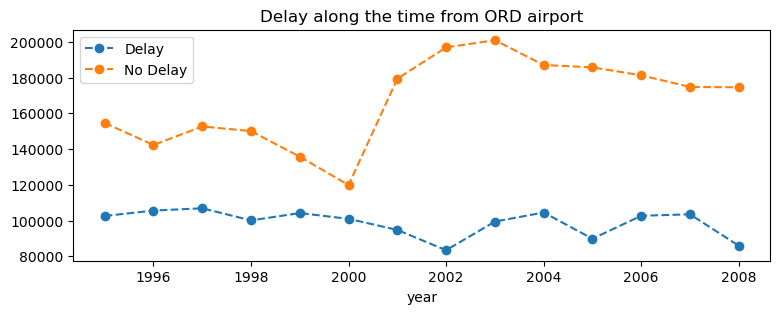

In [14]:
# Aumento nos voos para o aeroporto de ORD, devido por ser muito utilizado nas rotas dos voos
plot_data = df.filter(
    (col('Dest') == 'ORD')
).groupBy(
    'Dest', 'IsDelay', 'Year'
).agg(
    count("IsDelay").alias("count")
).orderBy('Year')

x = plot_data.filter(col('isDelay') == 1).select('Year').rdd.flatMap(list).collect()
y1 = plot_data.filter(col('isDelay') == 1).select('count').rdd.flatMap(list).collect()
y2 = plot_data.filter(col('isDelay') == 0).select('count').rdd.flatMap(list).collect()

plt.figure(figsize=(9,3))
plt.plot(x, y1, label='Delay', marker='o', linestyle='dashed')
plt.plot(x, y2, label='No Delay', marker='o', linestyle='dashed')
plt.xlabel('year')
plt.title('Delay along the time from ORD airport')
plt.legend()
plt.show()

### QUESTÃO 3 - Comparação dos padrões de voo antes e depois do 11 de setembro de 2001

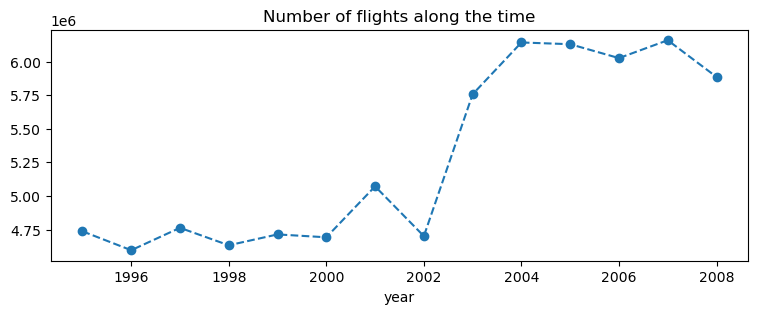

In [15]:
# Percebe-se uma queda nos voos após o ano de 2001, e uma grande volta no número de voos após 2002, nos Estados Unidos
plot_data = df.groupBy('Year').agg(
     count("Year").alias("count")
).orderBy('Year')

x = plot_data.select('Year').rdd.flatMap(list).collect()
y1 = plot_data.select('count').rdd.flatMap(list).collect()

plt.figure(figsize=(9,3))
plt.plot(x, y1, marker='o', linestyle='dashed')
plt.xlabel('year')
plt.title('Number of flights along the time')
plt.show()

### QUESTÃO 4 - RELAÇÃO ENTRE ATRASOS E COMPANHIAS AÉREAS

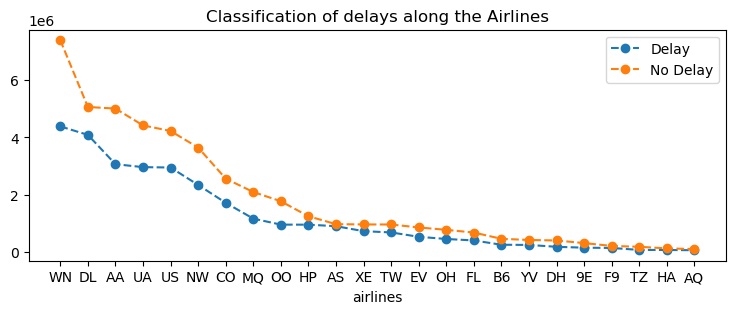

In [16]:
plot_data = df.groupBy(
    'UniqueCarrier', 'isDelay'
).agg(
     count("isDelay").alias("count"),
).orderBy(
    *['count'], ascending=False
)

x = plot_data.filter(col('isDelay') == 1).select('UniqueCarrier').rdd.flatMap(list).collect()
y1 = plot_data.filter(col('isDelay') == 1).select('count').rdd.flatMap(list).collect()
y2 = plot_data.filter(col('isDelay') == 0).select('count').rdd.flatMap(list).collect()

plt.figure(figsize=(9,3))
plt.plot(x, y1, label='Delay', marker='o', linestyle='dashed')
plt.plot(x, y2, label='No Delay', marker='o', linestyle='dashed')
plt.xlabel('airlines')
plt.title('Classification of delays along the Airlines')
plt.legend()
plt.show()

# WS -> Southwest Airlines